## Exploratory Data Analysis (EDA)

This section explores sales patterns, customer behavior, and product performance within the e-commerce dataset.

In [1]:
#Import pandas library
import pandas as pd

In [7]:
df = pd.read_csv("cleaned_dataset.csv", low_memory=False)

In [16]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Top-Selling Products

In [17]:
#Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [18]:
#Find top products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

The most frequently purchased product is **WHITE HANGING HEART T-LIGHT HOLDER**, followed by items like JUMBO BAG RED RETROSPOT and REGENCY CAKESTAND 3 TIER. This indicates that a small number of products dominate sales volume.

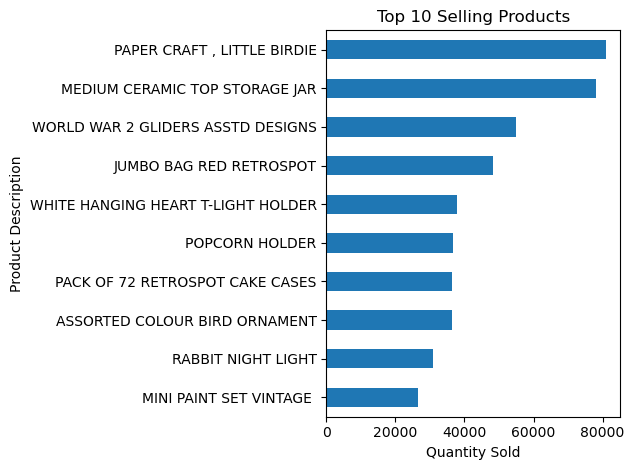

In [19]:
import matplotlib.pyplot as plt

plt.figure()

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

The analysis of top-selling products shows that “PAPER CRAFT, LITTLE BIRDIE” is the most purchased item by a significant margin, indicating exceptionally high demand. Other products such as storage jars, decorative items, and packaging materials also appear frequently, suggesting that customers tend to purchase home décor and utility items in bulk. A horizontal bar chart was used to improve readability due to long product names.

### Revenue by Country

In [20]:
#Top sales by country
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
top_countries

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

The United Kingdom generates the highest revenue by a significant margin, far exceeding other countries such as the Netherlands and EIRE. This suggests that the UK is the primary market for this business.

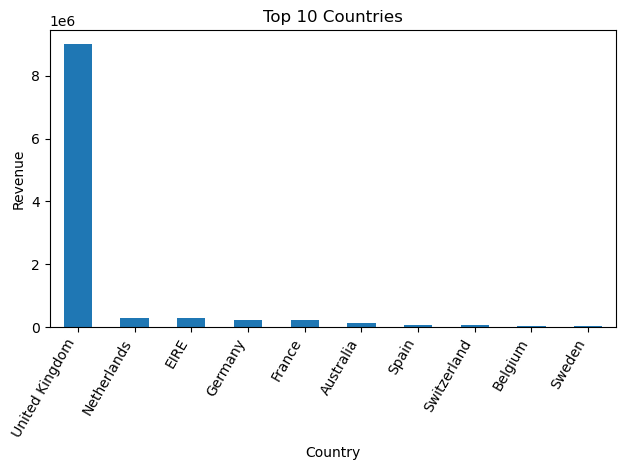

In [23]:
plt.figure()
top_countries.plot(kind='bar')

plt.title('Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

The United Kingdom generates significantly higher revenue compared to all other countries, indicating that it is the primary market for the business. Other countries such as the Netherlands, EIRE, and Germany contribute much smaller portions of total revenue.

### Monthly Sales Trend

In [25]:
#Monthly Sales Trend
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales

Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

Sales fluctuate over time, with a noticeable peak towards the end of the year (especially November). This suggests seasonal buying behavior, likely driven by holiday demand.

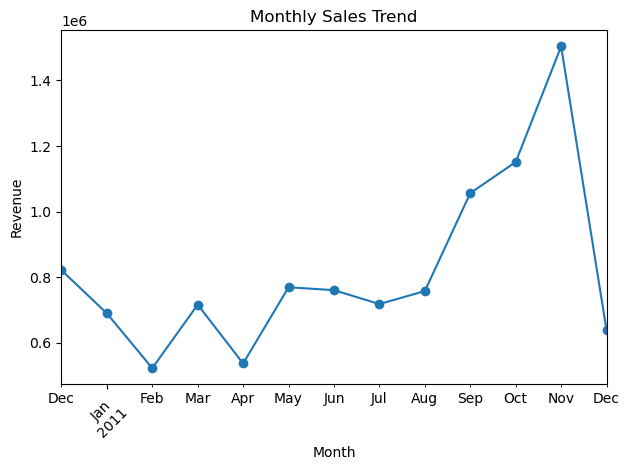

In [27]:
plt.figure()

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Sales show an overall upward trend throughout 2011, peaking in November. There is a noticeable drop in December, which may be due to incomplete data or seasonal slowdown after peak holiday sales.

### Most Purchased Products (by Quantity)

In [28]:
#Most purchased product
most_purchased = df['Description'].value_counts().head(10)

most_purchased

Description
WHITE HANGING HEART T-LIGHT HOLDER    2311
JUMBO BAG RED RETROSPOT               2109
REGENCY CAKESTAND 3 TIER              2007
PARTY BUNTING                         1699
LUNCH BAG RED RETROSPOT               1581
ASSORTED COLOUR BIRD ORNAMENT         1476
SET OF 3 CAKE TINS PANTRY DESIGN      1392
PACK OF 72 RETROSPOT CAKE CASES       1352
LUNCH BAG  BLACK SKULL.               1301
NATURAL SLATE HEART CHALKBOARD        1255
Name: count, dtype: int64

Products such as PAPER CRAFT and WORLD WAR 2 GLIDERS show very high purchase quantities, indicating strong customer demand for specific items.

The difference between top-selling products and most purchased products lies in measurement. Top-selling products are based on total quantity sold, while most purchased products are based on frequency of transactions. This distinction helps identify bulk-buy items versus frequently purchased items.

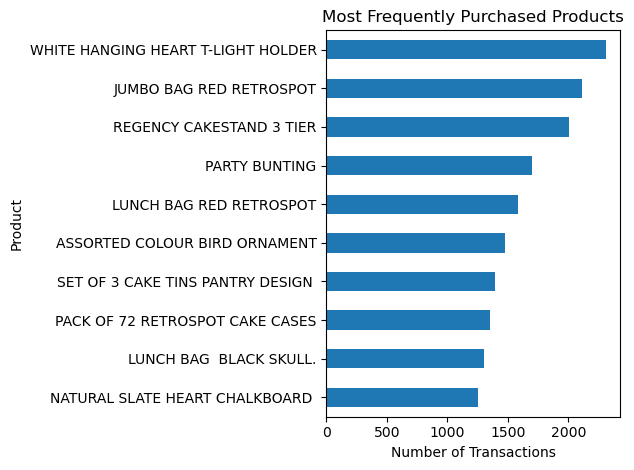

In [29]:
plt.figure()

most_purchased.sort_values().plot(kind='barh')

plt.title('Most Frequently Purchased Products')
plt.xlabel('Number of Transactions')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

### Top Customers by Revenue

In [30]:
#Customer purchasin behaviour
customer_spending = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

customer_spending.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

A small number of customers contribute a large portion of total revenue. This suggests that the business relies heavily on high-value customers.

Customer purchasing behavior analysis is limited to records with available CustomerID values. A significant portion of transactions lacks customer identification, which may impact the completeness and accuracy of the analysis. Therefore, the results represent only identifiable customers.

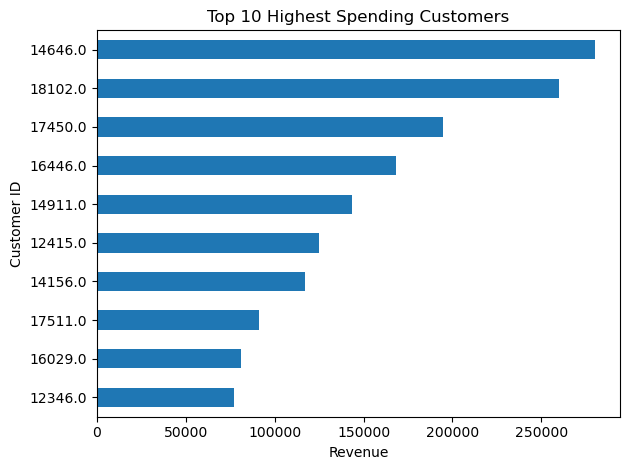

In [31]:
plt.figure()

customer_spending.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Highest Spending Customers')
plt.xlabel('Revenue')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()